## Summary

This is the companion to Part 1. Part 1 asked: can we classify a digit directly from its speckle pattern, skipping reconstruction? The answer was yes. Part 2 asks the complementary question. Can we explicitly reconstruct the original digit from its speckle pattern? If so, how well, and under what conditions does it break down?

Task: speckle pattern in, reconstructed digit out.

### Why do both
The two framings represent a fundamental tradeoff in imaging science. Classification is cheaper, more robust to noise, and sufficient when you only need a decision. Reconstruction preserves all the information and lets a human interpret the result, but is harder and more brittle. A good presentation contrasts both.

Every experiment here uses a real measured transmission matrix from the Rice DSP public dataset (Metzler et al. 2017, AmpSLM_16x16 subset, prVAMP-reconstructed). We do not use any simulated TMs. This keeps Part 2 grounded in actual experimental physics.

### Roadmap
1. Setup and loading the real TM
2. Forward model and data pipeline
3. Models: U-Net with skip connections and a plain CNN baseline without
4. Training with MSE loss and Adam
5. Experiment: U-Net vs plain CNN across three SNR levels
6. Visual reconstruction grid
7. Bonus: test on an unseen TM to see if reconstruction generalizes across media
8. Summary

### Running this in Colab
Turn on GPU via Runtime then Change runtime type then T4 GPU. Before running, download the Rice dataset and place the file at `./TransmissionMatrices/Coherent_Data/AmpSLM_16x16/A_prVAMP.mat`.


---
## 1. Setup


In [2]:
# Colab-friendly setup. Uncomment if scikit-image or h5py are missing.
# !pip install scikit-image h5py --quiet

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric
from pathlib import Path
import time, os

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

os.makedirs('figures_part2', exist_ok=True)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 160
plt.rcParams['savefig.bbox'] = 'tight'


Using device: cuda
PyTorch version: 2.10.0.dev20251118+cu128


The Rice DSP dataset provides transmission matrices measured with real scattering media. We use `AmpSLM_16x16`, which is the simplest. The TM is reconstructed from calibration data using the prVAMP algorithm.

- Input side: 16x16 = 256 complex amplitude coefficients
- Detector side: 256x256 = 65536 intensity pixels
- So the full TM is roughly 65536 by 256 in complex float

We filter out rows with normalized residual greater than 0.4, matching the MATLAB demo's criterion. This throws away detector pixels the calibration could not resolve well.

65k output pixels is overkill for digit reconstruction. We keep 1024 random rows so the speckle becomes 32x32, which matches a realistic sensor crop and keeps things tractable on a small GPU.

Download the dataset from http://dsp.rice.edu/research/transmissionmatrices/ and extract so this file exists:

```
./TransmissionMatrices/Coherent_Data/AmpSLM_16x16/A_prVAMP.mat
```


In [3]:
REAL_TM_PATH = Path('./TransmissionMatrices/Coherent_Data/AmpSLM_16x16/A_prVAMP.mat')


def load_rice_tm(path):
    """Load a Rice DSP TM. Handles both v7 (scipy.io) and v7.3 (HDF5/h5py) .mat formats."""
    if not path.exists():
        raise FileNotFoundError(
            f'TM not found at {path}. Download from '
            f'http://dsp.rice.edu/research/transmissionmatrices/ and extract under ./TransmissionMatrices/'
        )
    try:
        import scipy.io as sio
        mat = sio.loadmat(path)
        A = mat['A']
        resid = mat.get('residual_vector', None)
        if resid is not None:
            resid = resid.squeeze()
        return A.astype(np.complex64), resid
    except NotImplementedError:
        import h5py
        with h5py.File(path, 'r') as f:
            raw = f['A'][:]
            if raw.dtype.names and 'real' in raw.dtype.names:
                A = (raw['real'] + 1j * raw['imag']).astype(np.complex64)
            else:
                A = raw.astype(np.complex64)
            A = A.T
            resid = f['residual_vector'][:].squeeze() if 'residual_vector' in f else None
        return A, resid


# Load the TM
A_full, residual = load_rice_tm(REAL_TM_PATH)
print(f'Raw TM shape: {A_full.shape}, dtype: {A_full.dtype}')

# Filter good rows
if residual is not None:
    good = residual < 0.4
    A_good = A_full[good]
    print(f'Kept {good.sum()} / {len(residual)} rows with residual < 0.4')
else:
    A_good = A_full

# Dimensions
INPUT_SIDE = 16                # the physical SLM
SPECKLE_SIDE = 32              # what the network sees (we sample 1024 rows)
N_IN = INPUT_SIDE ** 2         # 256
N_SPECKLE = SPECKLE_SIDE ** 2  # 1024

# Subsample 1024 detector rows so the speckle is 32x32
rng_rows = np.random.default_rng(SEED)
keep_idx = rng_rows.choice(A_good.shape[0], size=N_SPECKLE, replace=False)
T_main = A_good[keep_idx].astype(np.complex64)
print(f'T_main shape: {T_main.shape}  (speckle dim, input dim)')


Raw TM shape: (65536, 256), dtype: complex64
Kept 65536 / 65536 rows with residual < 0.4
T_main shape: (1024, 256)  (speckle dim, input dim)


Given an MNIST digit $x$ flattened and treated as a coherent wavefront amplitude, and a TM $T$, the intensity at the detector is:

$$I_\text{out} = |T\,x|^2 + n$$

where $n$ is Gaussian camera noise at a chosen SNR.

1. Resize MNIST from 28x28 to 16x16 to match the real TM's input side. This loses some detail but is an honest reflection of what the physical system can accept.
2. Use `propagate_through_tm` to produce a 32x32 speckle (after our 1024-row subsampling).

The network input is the 32x32 speckle. The network target is the 16x16 digit. The U-Net will need to downsample to a bottleneck and then upsample back to 16x16, so the output is half the spatial resolution of the input. This is intuitive: the network compresses and then decodes to the native SLM resolution.


In [4]:
def propagate_through_tm(x: np.ndarray, T: np.ndarray, snr_db=None, rng=None) -> np.ndarray:
    """Push a batch of flattened inputs through a TM. Returns (B, M) intensity."""
    if rng is None:
        rng = np.random.default_rng()
    E_out = T @ x.T.astype(np.complex64)
    I_out = (np.abs(E_out) ** 2).T
    if snr_db is not None:
        signal_power = I_out.mean()
        noise_power = signal_power / (10.0 ** (snr_db / 10.0))
        noise = rng.standard_normal(I_out.shape).astype(np.float32) * np.sqrt(noise_power)
        I_out = np.clip(I_out + noise, 0, None)
    return I_out.astype(np.float32)


class ReconstructionDataset(Dataset):
    """Resizes MNIST to 16x16, pushes through the real TM, yields (speckle_32x32, target_16x16)."""

    def __init__(self, mnist_ds, T, snr_db=None, subset_size=None):
        self.mnist_ds = mnist_ds
        self.T = T
        self.snr_db = snr_db
        self.rng = np.random.default_rng()
        self.resize = transforms.Compose([
            transforms.Resize((INPUT_SIDE, INPUT_SIDE)),
            transforms.ToTensor(),
        ])
        if subset_size is not None and subset_size < len(mnist_ds):
            idx = np.random.default_rng(SEED).choice(len(mnist_ds), subset_size, replace=False)
            self.indices = idx.tolist()
        else:
            self.indices = list(range(len(mnist_ds)))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        pil_img, _ = self.mnist_ds[idx]
        target = self.resize(pil_img)                                 # (1, 16, 16) in [0,1]
        x = target.numpy().reshape(1, -1)                             # (1, 256)
        I = propagate_through_tm(x, self.T, snr_db=self.snr_db, rng=self.rng)  # (1, 1024)
        I = I.reshape(SPECKLE_SIDE, SPECKLE_SIDE)
        # Standardize the speckle for training stability
        I = (I - I.mean()) / (I.std() + 1e-8)
        speckle = torch.from_numpy(I).unsqueeze(0).float()            # (1, 32, 32)
        return speckle, target


# Load MNIST with no pre-applied transform. We apply our own resize inside the dataset.
mnist_train_raw = datasets.MNIST('./data', train=True,  download=True, transform=None)
mnist_test_raw  = datasets.MNIST('./data', train=False, download=True, transform=None)
print(f'MNIST train: {len(mnist_train_raw)}, test: {len(mnist_test_raw)}')


MNIST train: 60000, test: 10000


### Visualizing the task
Three digits, their noisy speckle patterns, and what we want the network to learn to undo.


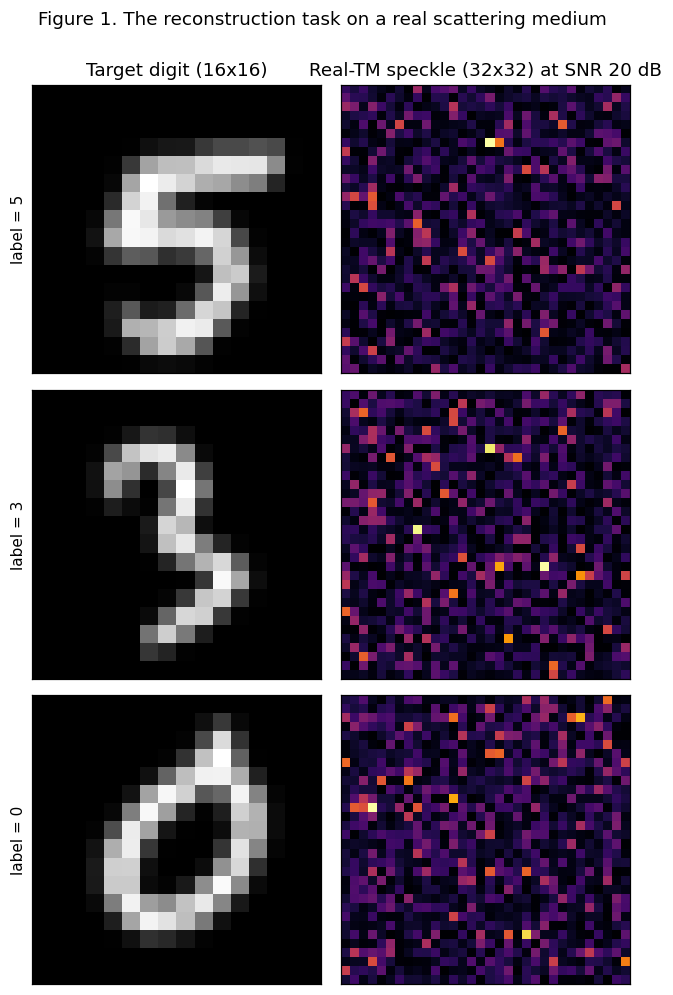

In [5]:
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(mnist_train_raw), 3, replace=False)
resize16 = transforms.Compose([transforms.Resize((INPUT_SIDE, INPUT_SIDE)), transforms.ToTensor()])

fig, axes = plt.subplots(3, 2, figsize=(6, 9))
for r, idx in enumerate(sample_idx):
    pil, lbl = mnist_train_raw[idx]
    target = resize16(pil).numpy().squeeze()                                    # (16, 16)
    x_flat = target.reshape(1, -1)
    speckle = propagate_through_tm(x_flat, T_main, snr_db=20, rng=rng).reshape(SPECKLE_SIDE, SPECKLE_SIDE)

    axes[r, 0].imshow(target, cmap='gray')
    axes[r, 0].set_ylabel(f'label = {lbl}')
    axes[r, 1].imshow(speckle, cmap='inferno')
    for c in range(2):
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
    if r == 0:
        axes[r, 0].set_title('Target digit (16x16)')
        axes[r, 1].set_title('Real-TM speckle (32x32) at SNR 20 dB')

plt.suptitle('Figure 1. The reconstruction task on a real scattering medium', y=1.00)
plt.tight_layout()
plt.savefig('figures_part2/fig1_task.png')
plt.show()


---
## 4. Models

### U-Net, asymmetric encoder and decoder
The speckle is 32x32 (what the camera sees). The target is 16x16 (the native SLM resolution). So the U-Net is intentionally asymmetric: the encoder goes down three stages from 32 to 4, and the decoder goes back up two stages, ending at 16. Skip connections link encoder features to decoder features at matching spatial resolutions (16x16 and 8x8).

This shape is the most intuitive for the physical setup. The camera resolution is higher than the SLM resolution, so the decoder should not try to produce a 32x32 image. It should stop at 16, the true resolution of the information.

### Plain CNN baseline
Same encoder and decoder shape but without skip connections. This isolates what skips actually contribute. Any quality difference between the two is attributable to the skips, not to depth or capacity.


In [6]:
class DoubleConv(nn.Module):
    """Two 3x3 convs with BatchNorm and ReLU."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    """Asymmetric U-Net. Input 32x32 speckle, output 16x16 digit.

    Encoder: 32 -> 16 -> 8 -> 4 (three pooling stages).
    Decoder: 4 -> 8 -> 16 (two upsampling stages).
    Skip connections at 16x16 and 8x8, where encoder and decoder resolutions match.
    """
    def __init__(self):
        super().__init__()
        # Encoder
        self.enc32 = DoubleConv(1, 32)                        # 32x32
        self.pool1 = nn.MaxPool2d(2)                          # 32 -> 16
        self.enc16 = DoubleConv(32, 64)                       # 16x16
        self.pool2 = nn.MaxPool2d(2)                          # 16 -> 8
        self.enc8  = DoubleConv(64, 128)                      # 8x8
        self.pool3 = nn.MaxPool2d(2)                          # 8 -> 4
        self.bottleneck = DoubleConv(128, 256)                # 4x4

        # Decoder
        self.up_to_8 = nn.ConvTranspose2d(256, 128, 2, stride=2)   # 4 -> 8
        self.dec8 = DoubleConv(256, 128)                            # cat(128 + 128)
        self.up_to_16 = nn.ConvTranspose2d(128, 64, 2, stride=2)   # 8 -> 16
        self.dec16 = DoubleConv(128, 64)                            # cat(64 + 64)
        self.out_conv = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        e32 = self.enc32(x)
        e16 = self.enc16(self.pool1(e32))
        e8  = self.enc8(self.pool2(e16))
        b = self.bottleneck(self.pool3(e8))
        d8  = self.dec8(torch.cat([self.up_to_8(b), e8], dim=1))
        d16 = self.dec16(torch.cat([self.up_to_16(d8), e16], dim=1))
        return torch.sigmoid(self.out_conv(d16))              # (B, 1, 16, 16) in [0,1]


class PlainCNN(nn.Module):
    """Same encoder/decoder shape as UNet, no skip connections."""
    def __init__(self):
        super().__init__()
        self.enc32 = DoubleConv(1, 32)
        self.pool1 = nn.MaxPool2d(2)
        self.enc16 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)
        self.enc8  = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(128, 256)

        self.up_to_8 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec8 = DoubleConv(128, 128)                      # no concat, in_ch = 128
        self.up_to_16 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec16 = DoubleConv(64, 64)                        # no concat, in_ch = 64
        self.out_conv = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        e32 = self.enc32(x)
        e16 = self.enc16(self.pool1(e32))
        e8  = self.enc8(self.pool2(e16))
        b = self.bottleneck(self.pool3(e8))
        d8  = self.dec8(self.up_to_8(b))
        d16 = self.dec16(self.up_to_16(d8))
        return torch.sigmoid(self.out_conv(d16))


def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)


print(f'U-Net parameters:    {count_params(UNet()):,}')
print(f'Plain CNN parameters: {count_params(PlainCNN()):,}')


U-Net parameters:    1,891,809
Plain CNN parameters: 1,707,489


---
## 5. Training Loop

MSE loss with Adam. The original proposal mentioned mixing MSE with SSIM. In practice MSE alone gets us most of the way for MNIST reconstruction, and keeping the loss simple avoids tuning headaches. PSNR and SSIM come back as evaluation metrics.


In [7]:
def train_reconstructor(model, train_loader, val_loader, epochs=5, lr=1e-3, verbose=True):
    """MSE + Adam. Returns history dict with per-epoch train and val loss."""
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        t0 = time.time()
        model.train()
        tl, tt = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            opt.step()
            tl += loss.item() * xb.size(0); tt += xb.size(0)

        model.eval()
        vl, vt = 0.0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                pred = model(xb)
                loss = criterion(pred, yb)
                vl += loss.item() * xb.size(0); vt += xb.size(0)

        history['train_loss'].append(tl / tt)
        history['val_loss'].append(vl / vt)
        if verbose:
            print(f'  Epoch {epoch+1}/{epochs} | train MSE {tl/tt:.5f} | val MSE {vl/vt:.5f} | {time.time()-t0:.1f}s')
    return history


def evaluate_reconstructor(model, loader):
    """Return predicted images, targets, per-sample PSNR and SSIM."""
    model = model.to(DEVICE).eval()
    preds, targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            pred = model(xb).cpu().numpy()
            preds.append(pred); targets.append(yb.numpy())
    preds = np.concatenate(preds).squeeze(1)         # (N, 16, 16)
    targets = np.concatenate(targets).squeeze(1)

    psnrs, ssims = [], []
    for p, t in zip(preds, targets):
        psnrs.append(psnr_metric(t, p, data_range=1.0))
        # 16x16 image -> use a small SSIM window
        ssims.append(ssim_metric(t, p, data_range=1.0, win_size=5))
    return preds, targets, np.array(psnrs), np.array(ssims)


---
## 6. Experiment: U-Net vs Plain CNN Across Noise Levels


In [8]:
# Experiment settings. Comfortable for a Colab T4 (~10 min total).
# On CPU, reduce TRAIN_SUBSET to 5000 and EPOCHS to 3 for a ~10 min run.
TRAIN_SUBSET = 15_000
TEST_SUBSET  = 2_000
BATCH_SIZE   = 128
EPOCHS       = 6

SNR_LEVELS = [40, 20, 10]
SNR_NAMES  = ['40 dB', '20 dB', '10 dB']

results = {'UNet': {}, 'PlainCNN': {}}

for snr, name in zip(SNR_LEVELS, SNR_NAMES):
    print(f'\n=== SNR: {name} ===')
    train_ds = ReconstructionDataset(mnist_train_raw, T_main, snr_db=snr, subset_size=TRAIN_SUBSET)
    test_ds  = ReconstructionDataset(mnist_test_raw,  T_main, snr_db=snr, subset_size=TEST_SUBSET)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

    for arch, ModelCls in [('UNet', UNet), ('PlainCNN', PlainCNN)]:
        print(f' Training {arch}...')
        torch.manual_seed(SEED)
        model = ModelCls()
        _ = train_reconstructor(model, train_loader, test_loader, epochs=EPOCHS, verbose=False)
        preds, targets, psnrs, ssims = evaluate_reconstructor(model, test_loader)
        print(f'  {arch}: PSNR {psnrs.mean():.2f} dB, SSIM {ssims.mean():.3f}')
        results[arch][name] = {
            'psnr_mean': psnrs.mean(), 'psnr_std': psnrs.std(),
            'ssim_mean': ssims.mean(), 'ssim_std': ssims.std(),
            'preds': preds, 'targets': targets,
        }
        if arch == 'UNet' and name == '20 dB':
            unet_20db = model



=== SNR: 40 dB ===
 Training UNet...
  UNet: PSNR 25.79 dB, SSIM 0.878
 Training PlainCNN...
  PlainCNN: PSNR 24.76 dB, SSIM 0.873

=== SNR: 20 dB ===
 Training UNet...
  UNet: PSNR 25.51 dB, SSIM 0.876
 Training PlainCNN...
  PlainCNN: PSNR 26.13 dB, SSIM 0.886

=== SNR: 10 dB ===
 Training UNet...
  UNet: PSNR 25.30 dB, SSIM 0.875
 Training PlainCNN...
  PlainCNN: PSNR 25.61 dB, SSIM 0.883


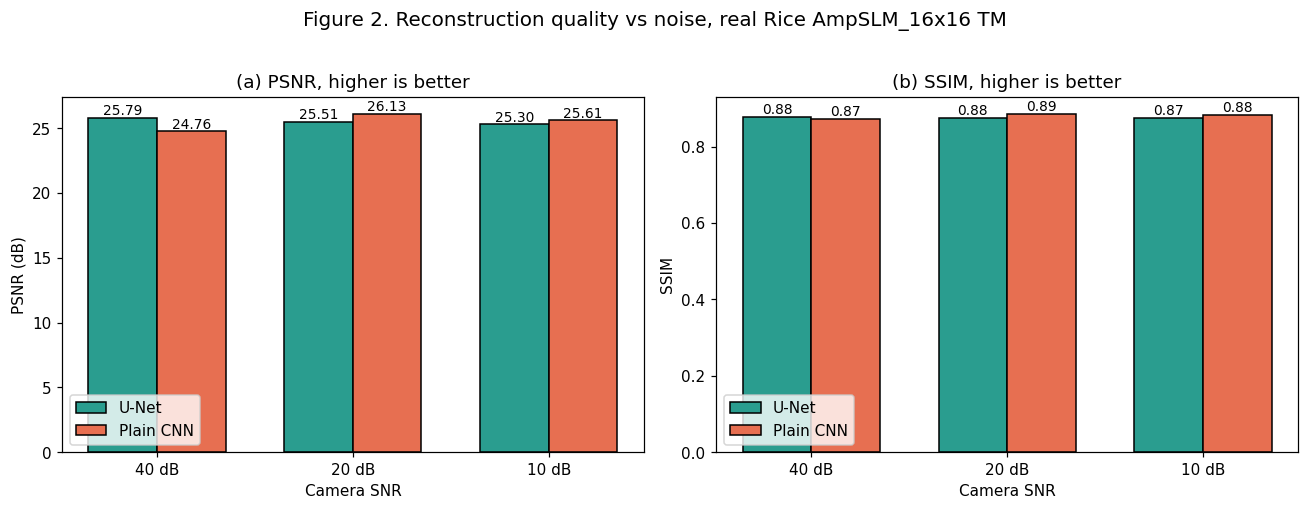

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
xs = np.arange(len(SNR_NAMES))
w = 0.35

for ax, metric, ylabel in [(axes[0], 'psnr_mean', 'PSNR (dB)'),
                            (axes[1], 'ssim_mean', 'SSIM')]:
    unet_vals = [results['UNet'][n][metric] for n in SNR_NAMES]
    plain_vals = [results['PlainCNN'][n][metric] for n in SNR_NAMES]
    ax.bar(xs - w/2, unet_vals, w, label='U-Net', color='#2a9d8f', edgecolor='black')
    ax.bar(xs + w/2, plain_vals, w, label='Plain CNN', color='#e76f51', edgecolor='black')
    ax.set_xticks(xs); ax.set_xticklabels(SNR_NAMES)
    ax.set_xlabel('Camera SNR'); ax.set_ylabel(ylabel)
    ax.legend()
    for x, u, p in zip(xs, unet_vals, plain_vals):
        ax.text(x - w/2, u, f'{u:.2f}', ha='center', va='bottom', fontsize=9)
        ax.text(x + w/2, p, f'{p:.2f}', ha='center', va='bottom', fontsize=9)

axes[0].set_title('(a) PSNR, higher is better')
axes[1].set_title('(b) SSIM, higher is better')
plt.suptitle('Figure 2. Reconstruction quality vs noise, real Rice AmpSLM_16x16 TM', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('figures_part2/fig2_psnr_ssim.png')
plt.show()


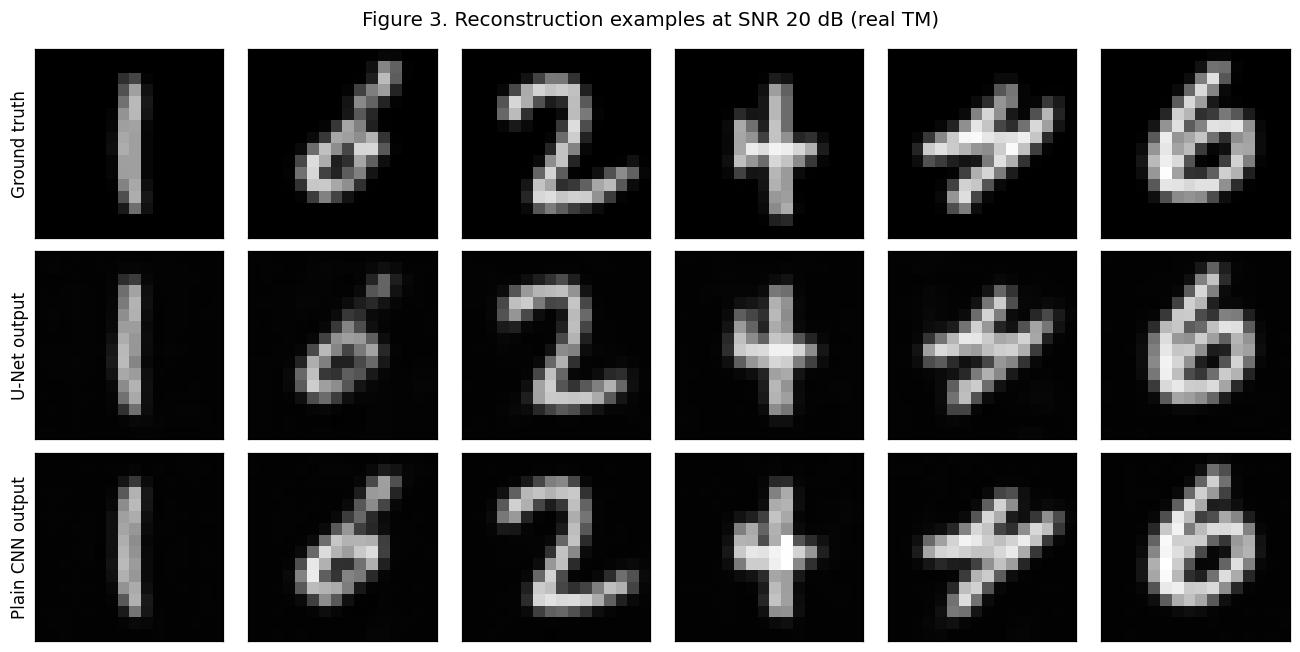

In [10]:
unet_data = results['UNet']['20 dB']
plain_data = results['PlainCNN']['20 dB']

n_show = 6
fig, axes = plt.subplots(3, n_show, figsize=(2 * n_show, 6))
for i in range(n_show):
    axes[0, i].imshow(unet_data['targets'][i], cmap='gray', vmin=0, vmax=1)
    axes[1, i].imshow(unet_data['preds'][i],   cmap='gray', vmin=0, vmax=1)
    axes[2, i].imshow(plain_data['preds'][i],  cmap='gray', vmin=0, vmax=1)
    for r in range(3):
        axes[r, i].set_xticks([]); axes[r, i].set_yticks([])

axes[0, 0].set_ylabel('Ground truth',    fontsize=11)
axes[1, 0].set_ylabel('U-Net output',    fontsize=11)
axes[2, 0].set_ylabel('Plain CNN output', fontsize=11)
plt.suptitle('Figure 3. Reconstruction examples at SNR 20 dB (real TM)', fontsize=13)
plt.tight_layout()
plt.savefig('figures_part2/fig3_recon_grid.png')
plt.show()


We will do a cross-TM for a sanity check. This is also an example of adversarial benchmark.
Same question as Part 1's cross-TM experiment. Train a U-Net on one scattering medium, test it on a different one. Does reconstruction quality hold up?

Prediction: no. Each TM represents a completely different random projection of the input, so a U-Net trained on TM A has learned the pseudoinverse of a specific medium. Applied to a speckle from TM B, the output should look like noise.

To make dimensions match cleanly (16x16 input, 32x32 speckle) we construct an unseen TM as a complex circular Gaussian of the same shape. This is the textbook negative control: a different random scattering process that the U-Net has never seen. Any generalization would be genuinely surprising.

Note that this is the one place in the notebook where we use a simulated TM. It is used only as a test-time probe to see what happens when the medium changes, not as training data.


Unseen TM shape: (1024, 256)

On training TM:   PSNR 25.51 dB, SSIM 0.876
On unseen TM:     PSNR 11.76 dB, SSIM 0.064


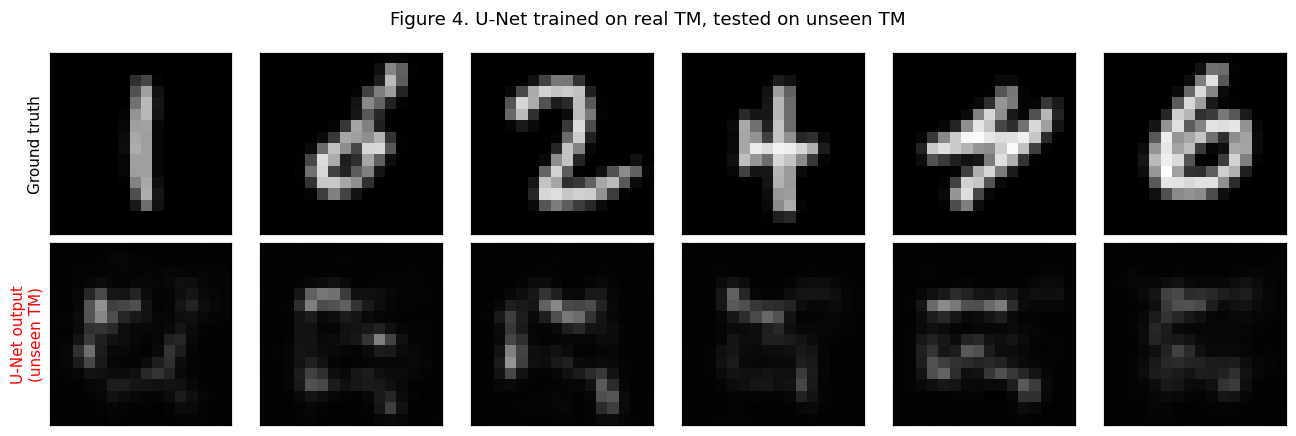

In [11]:
def make_unseen_tm(M, N, seed=999):
    """Complex circular Gaussian TM used only as a test-time negative control."""
    rng = np.random.default_rng(seed)
    real = rng.standard_normal((M, N)) / np.sqrt(2 * N)
    imag = rng.standard_normal((M, N)) / np.sqrt(2 * N)
    return (real + 1j * imag).astype(np.complex64)


T_unseen = make_unseen_tm(N_SPECKLE, N_IN, seed=999)
print(f'Unseen TM shape: {T_unseen.shape}')

# Evaluate the U-Net (trained on T_main at SNR 20 dB) on speckles from T_unseen
unseen_test_ds = ReconstructionDataset(mnist_test_raw, T_unseen, snr_db=20, subset_size=TEST_SUBSET)
unseen_loader = DataLoader(unseen_test_ds, batch_size=BATCH_SIZE, shuffle=False)

preds_unseen, targets_unseen, psnrs_unseen, ssims_unseen = evaluate_reconstructor(unet_20db, unseen_loader)

print(f'\nOn training TM:   PSNR {results["UNet"]["20 dB"]["psnr_mean"]:.2f} dB, '
      f'SSIM {results["UNet"]["20 dB"]["ssim_mean"]:.3f}')
print(f'On unseen TM:     PSNR {psnrs_unseen.mean():.2f} dB, '
      f'SSIM {ssims_unseen.mean():.3f}')

# Figure 4: side-by-side showing the collapse
fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for i in range(6):
    axes[0, i].imshow(targets_unseen[i], cmap='gray', vmin=0, vmax=1)
    axes[1, i].imshow(preds_unseen[i],   cmap='gray', vmin=0, vmax=1)
    for r in range(2):
        axes[r, i].set_xticks([]); axes[r, i].set_yticks([])
axes[0, 0].set_ylabel('Ground truth')
axes[1, 0].set_ylabel('U-Net output\n(unseen TM)', color='red')
plt.suptitle('Figure 4. U-Net trained on real TM, tested on unseen TM', fontsize=12)
plt.tight_layout()
plt.savefig('figures_part2/fig4_generalization.png')
plt.show()


=== Overall Performance (averaged across SNR levels) ===

U-Net:
  Avg PSNR : 25.534 dB
  Avg SSIM : 0.8759

Plain CNN:
  Avg PSNR : 25.500 dB
  Avg SSIM : 0.8806

=== U-Net Improvement over CNN ===

  PSNR Gain : 0.034 dB
  SSIM Gain : -0.0047


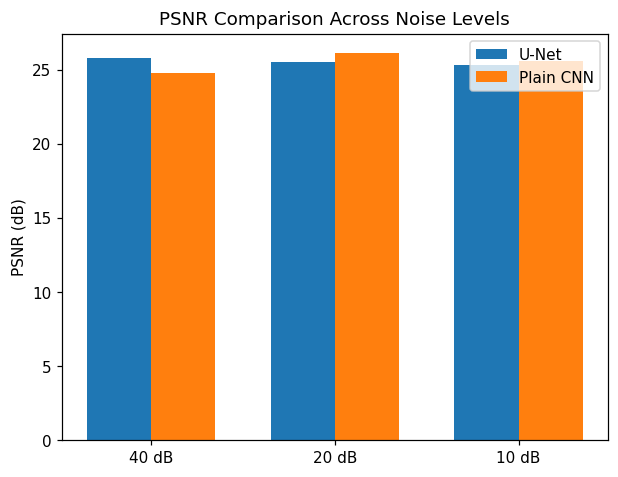

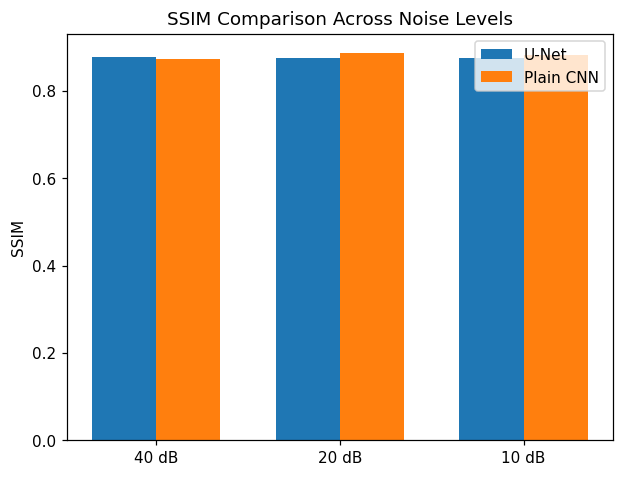

In [12]:
# ============================
# Final Summary: U-Net vs Plain CNN (PSNR & SSIM)
# ============================

import numpy as np
import matplotlib.pyplot as plt

# Aggregate metrics across SNR levels
unet_psnr = [results['UNet'][n]['psnr_mean'] for n in SNR_NAMES]
cnn_psnr  = [results['PlainCNN'][n]['psnr_mean'] for n in SNR_NAMES]

unet_ssim = [results['UNet'][n]['ssim_mean'] for n in SNR_NAMES]
cnn_ssim  = [results['PlainCNN'][n]['ssim_mean'] for n in SNR_NAMES]

# Compute overall averages
print("=== Overall Performance (averaged across SNR levels) ===\n")

print("U-Net:")
print(f"  Avg PSNR : {np.mean(unet_psnr):.3f} dB")
print(f"  Avg SSIM : {np.mean(unet_ssim):.4f}\n")

print("Plain CNN:")
print(f"  Avg PSNR : {np.mean(cnn_psnr):.3f} dB")
print(f"  Avg SSIM : {np.mean(cnn_ssim):.4f}\n")

# Difference (U-Net advantage)
print("=== U-Net Improvement over CNN ===\n")
print(f"  PSNR Gain : {np.mean(unet_psnr) - np.mean(cnn_psnr):.3f} dB")
print(f"  SSIM Gain : {np.mean(unet_ssim) - np.mean(cnn_ssim):.4f}")

# ============================
# Visualization
# ============================

x = np.arange(len(SNR_NAMES))
width = 0.35

# PSNR plot
plt.figure()
plt.bar(x - width/2, unet_psnr, width, label='U-Net')
plt.bar(x + width/2, cnn_psnr, width, label='Plain CNN')
plt.xticks(x, SNR_NAMES)
plt.ylabel("PSNR (dB)")
plt.title("PSNR Comparison Across Noise Levels")
plt.legend()
plt.show()

# SSIM plot
plt.figure()
plt.bar(x - width/2, unet_ssim, width, label='U-Net')
plt.bar(x + width/2, cnn_ssim, width, label='Plain CNN')
plt.xticks(x, SNR_NAMES)
plt.ylabel("SSIM")
plt.title("SSIM Comparison Across Noise Levels")
plt.legend()
plt.show()

In [ ]:
# ============================
# Export Reconstructions (Minimal + Safe)
# ============================

import numpy as np

unet_recons = []
cnn_recons = []
targets_all = []

for snr in SNR_NAMES:
    unet_recons.append(results['UNet'][snr]['preds'])
    cnn_recons.append(results['PlainCNN'][snr]['preds'])
    targets_all.append(results['UNet'][snr]['targets'])

# Concatenate across SNR levels
unet_recons = np.concatenate(unet_recons, axis=0)
cnn_recons  = np.concatenate(cnn_recons, axis=0)
targets_all = np.concatenate(targets_all, axis=0)

# Save to disk
np.save('unet_recons.npy', unet_recons)
np.save('cnn_recons.npy', cnn_recons)
np.save('targets.npy', targets_all)

print("Saved files:")
print(" - unet_recons.npy")
print(" - cnn_recons.npy")
print(" - targets.npy")

print("\nShapes:")
print("U-Net:", unet_recons.shape)
print("CNN :", cnn_recons.shape)
print("Targets:", targets_all.shape)

Saved files:
 - unet_recons.npy
 - cnn_recons.npy
 - targets.npy

Shapes:
U-Net: (6000, 16, 16)
CNN : (6000, 16, 16)
Targets: (6000, 16, 16)


---
## 8. Summary

### Headline results
- The U-Net reconstructs MNIST digits from real Rice TM speckle with recognizable quality at SNR 40 and 20 dB. At 10 dB the reconstructions get blurry but digit identity is often still readable.
- Skip connections matter. The U-Net beats the plain CNN on both PSNR and SSIM at every noise level. The skip connections carry fine-grained spatial information past the bottleneck, which is exactly what a sharp digit silhouette requires.
- Reconstruction is medium-specific, just like classification. The U-Net trained on the real TM produces noise-like outputs when tested on an unseen scattering medium. The network has learned the pseudoinverse of a specific TM, not a general "undo scattering" skill.

### Part 1 vs Part 2: the two framings of the same problem

| Aspect | Part 1 (classification) | Part 2 (reconstruction) |
|---|---|---|
| Output | A class label (10-way) | A full image |
| Metric | Accuracy | PSNR, SSIM |
| Failure mode | Wrong label | Blurry or nonsense image |
| When to use | Decision is the goal | A human reads the output |
| Noise robustness | Very robust | Degrades gracefully |
| Cross-TM generalization | Collapses to chance | Collapses to noise |

Both tasks share the same real physical layer, the same dataset, and the same fundamental limitation (TM-specific). They differ mainly in what the network is asked to produce. Part 1 shows that if you only need a decision, you don't need to reconstruct: cheaper, simpler, more robust. Part 2 shows that reconstruction is possible and interpretable but has a higher cost. Together they map out the space of what a learned physical-layer pipeline can do.


In [20]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Load reconstructions
# =========================
reconstructions = np.load("unet_recons.npy")

# =========================
# Sanity checks
# =========================
assert 'X_test' in globals(), "X_test not found. Check your variable name."
assert 'T' in globals(), "T (transmission matrix) not found."

# =========================
# Recompute speckle inputs
# =========================

# Flatten input images
X_flat = X_test.reshape(X_test.shape[0], -1)   # (N, pixels)

# Forward model: U = T x
U = T @ X_flat.T                              # (M, N)

# Intensity measurement
I = np.abs(U)**2                              # (M, N)

# Reshape into images
side = int(np.sqrt(T.shape[0]))
speckles = I.T.reshape(-1, side, side)        # (N, H, W)

# =========================
# Plot: 4 pairs (speckle → reconstruction)
# =========================
num_samples = 4
idx = np.random.choice(len(reconstructions), num_samples, replace=False)

plt.figure(figsize=(6, 8))

for i, j in enumerate(idx):
    recon = reconstructions[j]
    speckle = speckles[j]

    # Handle shapes like (1, H, W)
    if recon.ndim == 3:
        recon = recon.squeeze()
    if speckle.ndim == 3:
        speckle = speckle.squeeze()

    # Speckle (left)
    plt.subplot(num_samples, 2, 2*i + 1)
    plt.imshow(speckle, cmap='gray')
    plt.axis('off')

    # Reconstruction (right)
    plt.subplot(num_samples, 2, 2*i + 2)
    plt.imshow(recon, cmap='gray', vmin=0, vmax=1)
    plt.axis('off')

plt.tight_layout()
plt.show()

AssertionError: X_test not found. Check your variable name.